# RFM - Customer Segmentation & Retention Analysis
Perusahaan memiliki pelanggan dengan karakteristik dan perilaku transaksi
yang berbeda. Sebagian pelanggan bertransaksi secara rutin dan memberikan
kontribusi pendapatan yang besar, sedangkan sebagian lainnya sudah lama
tidak melakukan pembelian dan memiliki risiko churn.

Analisis RFM digunakan untuk mengelompokkan pelanggan berdasarkan:

- Recency: waktu sejak transaksi terakhir.
- Frequency: jumlah transaksi yang dilakukan pelanggan.
- Monetary: total nilai transaksi pelanggan.

Hasil segmentasi diharapkan membantu perusahaan menentukan strategi
retensi, promosi, cross-selling, upselling, dan win-back campaign yang
lebih tepat sasaran.

# Business Problem
1. Bagaimana segmentasi pelanggan berdasarkan perilaku transaksi dapat
digunakan untuk meningkatkan retensi pelanggan dan kontribusi pendapatan perusahaan?
2. Bagaimana distribusi pelanggan berdasarkan nilai Recency, Frequency, dan Monetary?
3. Segmen pelanggan mana yang memberikan kontribusi pendapatan terbesar?
4. Segmen pelanggan mana yang memiliki risiko churn tertinggi?
5. Membership tier dan acquisition channel mana yang menghasilkan pelanggan paling bernilai?
6. Produk dan kategori apa yang paling banyak diminati oleh pelanggan bernilai tinggi?
7. Pelanggan mana yang harus diprioritaskan untuk program retensi dan win-back campaign?

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

!pip install squarify
import squarify

# Data Wrangling

## Load Data

In [ ]:
!kaggle datasets download meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026
!unzip e-commerce-customer-behavior-and-sales-20202026.zip

Dataset URL: https://www.kaggle.com/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026
License(s): apache-2.0
100% 1.31M/1.31M [00:00<00:00, 103MB/s]

Archive:  e-commerce-customer-behavior-and-sales-20202026.zip
  inflating: customers.csv           
  inflating: monthly_revenue.csv     
  inflating: orders.csv              
  inflating: product_summary.csv     


In [ ]:
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
products_summary = pd.read_csv('product_summary.csv')
monthly_revenue = pd.read_csv('monthly_revenue.csv')

## Assesing Data

In [ ]:
def data_overview(df, dataset_name):
    print(f"Dataset: {dataset_name}")
    print("-" * 50)
    print(f"Jumlah baris   : {df.shape[0]:,}")
    print(f"Jumlah kolom   : {df.shape[1]:,}")
    print(f"Jumlah duplikat: {df.duplicated().sum():,}")

    display(df.head())

    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "unique": df.nunique()
    })

    display(summary)

In [ ]:
data_overview(customers, "Customers")
data_overview(orders, "Orders")
data_overview(monthly_revenue, "Monthly Revenue")
data_overview(products_summary, "Products Summary")

Dataset: Customers
--------------------------------------------------
Jumlah baris   : 8,000
Jumlah kolom   : 20
Jumlah duplikat: 0


,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


,dtype,missing,missing_pct,unique
customer_id,object,0,0.0,8000
country,object,0,0.0,20
age,int64,0,0.0,57
gender,object,0,0.0,3
membership_tier,object,0,0.0,4
registration_date,object,0,0.0,1862
total_orders,int64,0,0.0,79
total_spend_usd,float64,0,0.0,7864
avg_order_value_usd,float64,0,0.0,6365
days_since_last_purchase,int64,0,0.0,336


Dataset: Orders
--------------------------------------------------
Jumlah baris   : 25,000
Jumlah kolom   : 28
Jumlah duplikat: 0


,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,payment_method,device_used,delivery_days,delivery_date,order_status,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,Credit Card,Desktop,3,2020-08-30,Delivered,0,NaN,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,Credit Card,Mobile,2,2024-04-13,Delivered,0,NaN,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,PayPal,Desktop,3,2023-06-28,Delivered,0,4.0,3.2,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,...,Credit Card,Tablet,2,2020-08-18,Returned,1,NaN,32.2,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,Debit Card,Mobile,5,2020-04-29,Delivered,0,2.8,54.7,2,1


...

,year,month,quarter,orders,revenue_usd,avg_order_value,avg_discount_pct,return_rate,unique_customers,new_customers
0,2020,1,Q1,266,35415.25,133.14,5.68,0.0,261,100
1,2020,2,Q1,268,34304.78,128.00,6.06,0.0,263,93
2,2020,3,Q1,258,32642.23,126.52,5.21,0.0,254,81
3,2020,4,Q2,281,34865.39,124.08,5.27,0.0,275,99
4,2020,5,Q2,286,38625.73,135.06,5.84,0.0,282,113


,dtype,missing,missing_pct,unique
year,int64,0,0.0,7
month,int64,0,0.0,12
quarter,object,0,0.0,4
orders,int64,0,0.0,45
revenue_usd,float64,0,0.0,75
avg_order_value,float64,0,0.0,74
avg_discount_pct,float64,0,0.0,64
return_rate,float64,0,0.0,1
unique_customers,int64,0,0.0,44
new_customers,int64,0,0.0,32


Dataset: Products Summary
--------------------------------------------------
Jumlah baris   : 140
Jumlah kolom   : 9
Jumlah duplikat: 0


,category,product_name,total_orders,total_revenue_usd,avg_price,avg_rating,return_rate,avg_discount_pct,avg_delivery_days
0,Automotive,Air Freshener,87,10543.38,73.61,3.95,7.0,4.54,4.66
1,Automotive,Car Phone Mount,86,10950.18,73.82,3.99,12.0,5.76,4.08
2,Automotive,Car Vacuum Cleaner,73,8588.32,71.15,4.11,7.0,7.53,4.38
3,Automotive,Dashcam 4K,79,9402.79,68.25,4.06,6.0,4.18,4.20
4,Automotive,Jump Starter Pack,68,8338.79,78.06,4.00,10.0,4.63,4.03


,dtype,missing,missing_pct,unique
category,object,0,0.0,14
product_name,object,0,0.0,140
total_orders,int64,0,0.0,108
total_revenue_usd,float64,0,0.0,140
avg_price,float64,0,0.0,137
avg_rating,float64,0,0.0,40
return_rate,float64,0,0.0,15
avg_discount_pct,float64,0,0.0,112
avg_delivery_days,float64,0,0.0,72


In [ ]:
display(customers.describe(include="all").T)
display(orders.describe(include="all").T)
display(monthly_revenue.describe(include="all").T)
display(products_summary.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,8000,8000,C07984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8000,20,United States,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,8000.0,NaN,NaN,NaN,35.616375,11.170455,18.0,27.0,35.0,43.0,75.0
gender,8000,3,Female,3895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_tier,8000,4,Free,4443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
registration_date,8000,1862,2026-02-18,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_orders,8000.0,NaN,NaN,NaN,16.54525,14.681064,1.0,5.0,12.0,23.0,79.0
total_spend_usd,8000.0,NaN,NaN,NaN,1558.64235,2284.094953,4.89,336.055,845.7,1892.165,61282.48
avg_order_value_usd,8000.0,NaN,NaN,NaN,94.845566,78.992885,5.0,44.69,72.27,118.56,1051.73
days_since_last_purchase,8000.0,NaN,NaN,NaN,59.583875,60.610355,0.0,16.0,41.0,84.0,582.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,25000,25000,O025000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,25000,7663,C03007,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,25000,2281,2020-08-25,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,25000.0,NaN,NaN,NaN,2022.65284,1.814996,2020.0,2021.0,2023.0,2024.0,2026.0
month,25000.0,NaN,NaN,NaN,6.35228,3.514614,1.0,3.0,6.0,9.0,12.0
quarter,25000,4,Q1,6963,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,25000,7,Monday,3658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,25000,140,Portable Charger 20000mAh,497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,25000,14,Electronics,4526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_price_usd,25000.0,NaN,NaN,NaN,68.12403,57.258933,3.36,29.25,51.53,87.8775,697.03


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,75.0,NaN,NaN,NaN,2022.64,1.820603,2020.0,2021.0,2023.0,2024.0,2026.0
month,75.0,NaN,NaN,NaN,6.32,3.522745,1.0,3.0,6.0,9.0,12.0
quarter,75,4,Q1,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orders,75.0,NaN,NaN,NaN,273.293333,17.005383,237.0,262.0,269.0,285.5,316.0
revenue_usd,75.0,NaN,NaN,NaN,34468.353333,3436.60988,25922.18,31878.58,34020.34,36749.42,44793.18
avg_order_value,75.0,NaN,NaN,NaN,126.048533,8.841044,109.38,119.905,125.54,130.955,153.29
avg_discount_pct,75.0,NaN,NaN,NaN,5.632933,0.598473,4.34,5.22,5.59,6.185,7.06
return_rate,75.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
unique_customers,75.0,NaN,NaN,NaN,268.4,16.604298,236.0,256.0,263.0,281.0,309.0
new_customers,75.0,NaN,NaN,NaN,97.12,9.366357,76.0,93.0,97.0,102.0,122.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
category,140,14,Automotive,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,140,140,Air Freshener,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_orders,140.0,NaN,NaN,NaN,168.171429,113.141087,38.0,80.75,142.5,185.0,466.0
total_revenue_usd,140.0,NaN,NaN,NaN,21135.674357,27013.447877,3231.83,7723.1325,10362.085,16083.3,124113.88
avg_price,140.0,NaN,NaN,NaN,60.435286,33.624582,20.0,31.1325,55.055,80.4475,143.34
avg_rating,140.0,NaN,NaN,NaN,3.999714,0.095631,3.6,3.96,4.01,4.0525,4.23
return_rate,140.0,NaN,NaN,NaN,8.75,2.423283,3.0,7.0,8.0,10.0,17.0
avg_discount_pct,140.0,NaN,NaN,NaN,5.582286,0.825639,3.31,5.1075,5.58,6.115,7.75
avg_delivery_days,140.0,NaN,NaN,NaN,4.169214,0.240506,3.43,4.0475,4.16,4.2725,4.86


## Data Cleaning

In [ ]:
# Datetime
customers['registration_date'] = pd.to_datetime(
    customers["registration_date"],
    errors="coerce"
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

In [ ]:
# drop kolom customer_rating
orders.drop(columns=["customer_rating"], inplace=True)


In [ ]:
data_overview(orders, "Orders")


Dataset: Orders
--------------------------------------------------
Jumlah baris   : 25,000
Jumlah kolom   : 27
Jumlah duplikat: 0


,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,total_amount_usd,payment_method,device_used,delivery_days,delivery_date,order_status,returned,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,74.23,Credit Card,Desktop,3,2020-08-30,Delivered,0,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,24.27,Credit Card,Mobile,2,2024-04-13,Delivered,0,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,94.86,PayPal,Desktop,3,2023-06-28,Delivered,0,3.2,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,...,47.10,Credit Card,Tablet,2,2020-08-18,Returned,1,32.2,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,208.02,Debit Card,Mobile,5,2020-04-29,Delivered,0,54.7,2,1


,dtype,missing,missing_pct,unique
order_id,object,0,0.0,25000
customer_id,object,0,0.0,7663
order_date,datetime64[ns],0,0.0,2281
year,int64,0,0.0,7
month,int64,0,0.0,12
quarter,object,0,0.0,4
day_of_week,object,0,0.0,7
product_name,object,0,0.0,140
category,object,0,0.0,14
unit_price_usd,float64,0,0.0,12013


In [ ]:
# RFM dilakukan ketika order telah selesai
completed_orders = orders[
    orders["order_status"].str.lower() == "delivered"
].copy()

# EDA

## KPI

In [ ]:
total_customer = customers['customer_id'].nunique()
total_order = completed_orders['order_id'].count()
total_revenue = completed_orders['total_amount_usd'].sum()
customer_transaction = orders['customer_id'].count()
avg_order_value = total_revenue / total_order

print(f"Total customers       : {total_customer:,}")
print(f"Transaction customers : {customer_transaction:,}")
print(f"Completed orders      : {total_order:,}")
print(f"Total revenue         : ${total_revenue:,.2f}")
print(f"Average order value   : ${avg_order_value:,.2f}")


Total customers       : 8,000
Transaction customers : 25,000
Completed orders      : 20,497
Total revenue         : $2,585,126.50
Average order value   : $126.12


## Tren Bulanan

In [ ]:
monyhly_sales =(
    completed_orders
    .set_index("order_date")
    .resample("MS")
    .agg(
        revenue = ("total_amount_usd","sum"),
        total_orders = ("order_id","nunique"),
        active_customers = ("customer_id","nunique")
    ).reset_index()
)


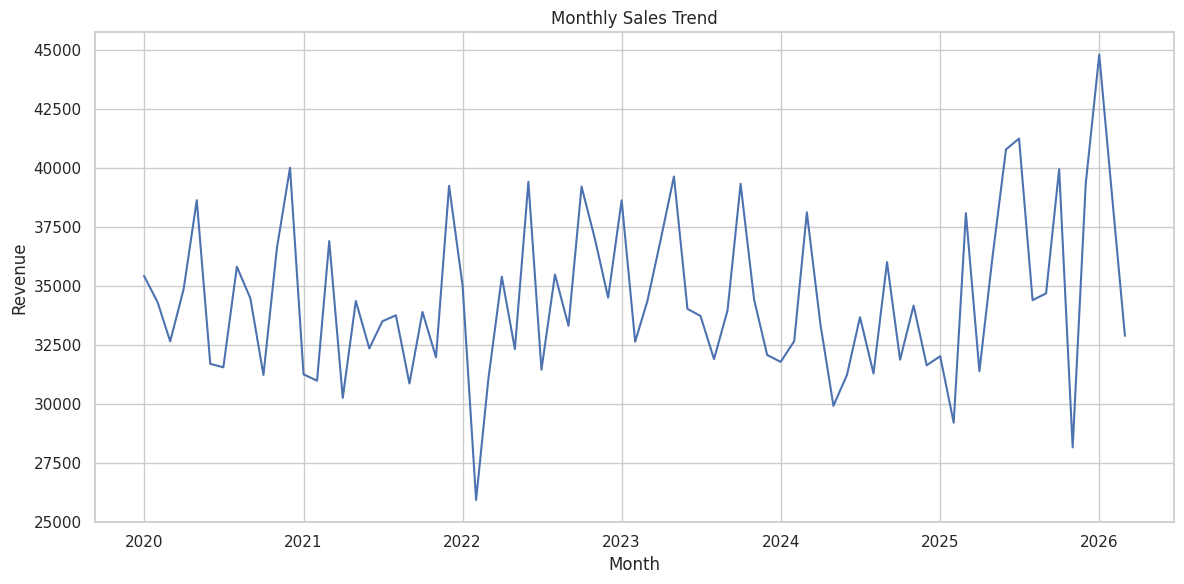

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data = monyhly_sales,
    x = "order_date",
    y = "revenue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## Tren Jumlah Order

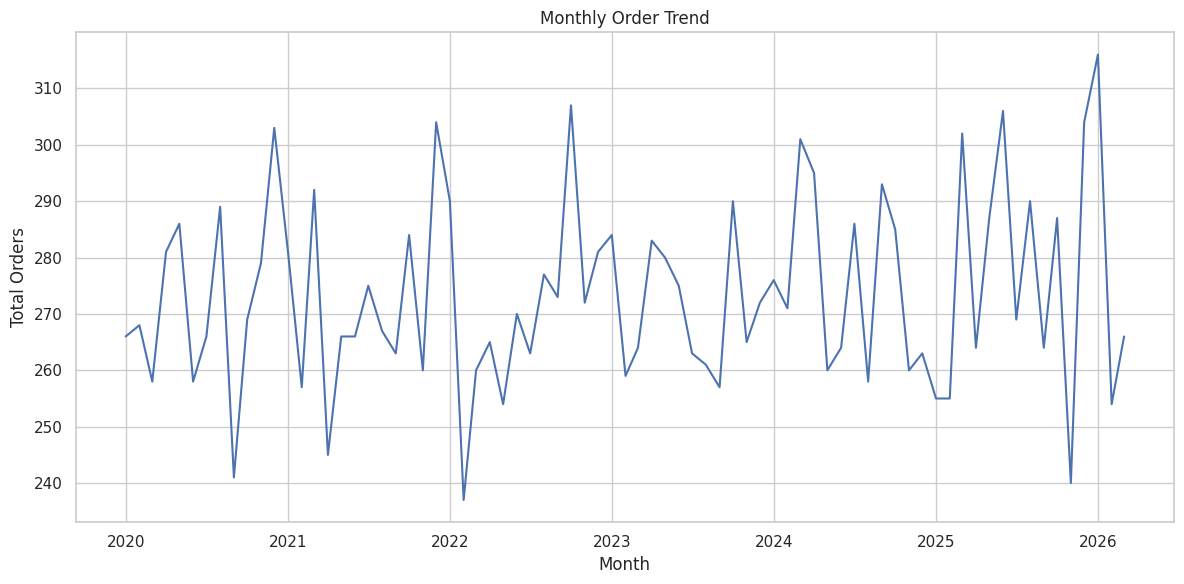

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data = monyhly_sales,
    x = "order_date",
    y = "total_orders"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()

## Distribusi Order

In [ ]:
order_status_summary = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status_summary.columns = [
    "order_status",
    "total_orders"
]

display(order_status_summary)

,order_status,total_orders
0,Delivered,20497
1,Returned,2020
2,Cancelled,1456
3,Processing,1027


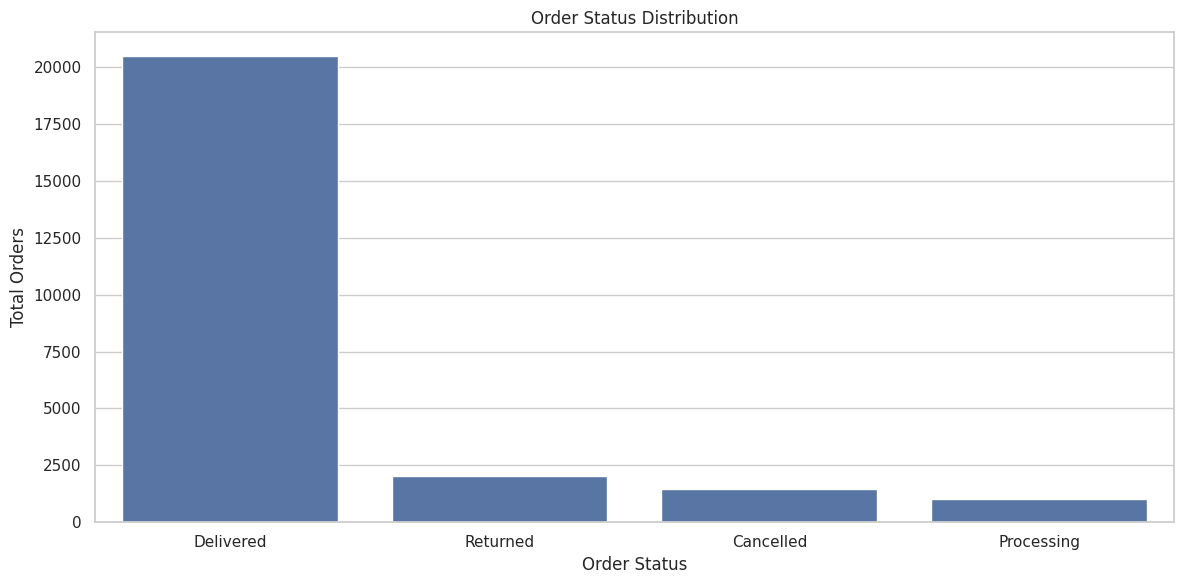

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data = order_status_summary,
    x = "order_status",
    y = "total_orders"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()

## Distribusi Membership

In [ ]:
membership_summary = (
    customers['membership_tier']
    .value_counts()
    .reset_index()
)

membership_summary.columns = [
    "membership_tier",
    "total_customers"
]

display(membership_summary)

,membership_tier,total_customers
0,Free,4443
1,Silver,1736
2,Gold,1177
3,Platinum,644


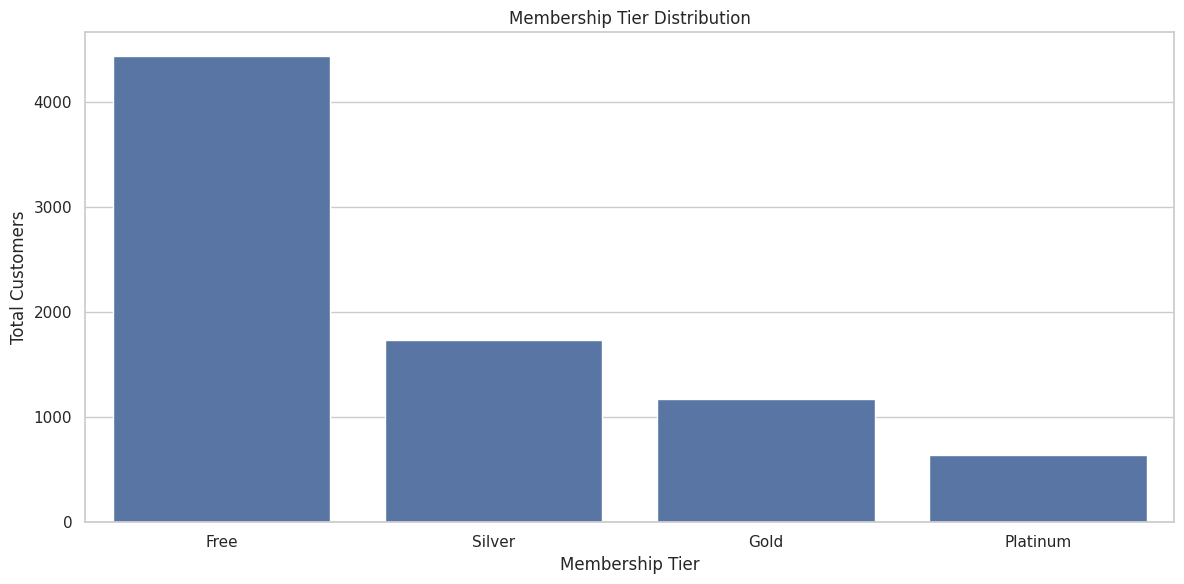

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data = membership_summary,
    x = "membership_tier",
    y = "total_customers"
)

plt.title("Membership Tier Distribution")
plt.xlabel("Membership Tier")
plt.ylabel("Total Customers")
plt.tight_layout()
plt.show()

# RFM

In [ ]:
last_transaction_date = completed_orders["order_date"].max()
snapshot_date = last_transaction_date + pd.Timedelta(days=1)

print(f"Last transaction date: {last_transaction_date}")
print(f"Snapshot date: {snapshot_date}")

Last transaction date: 2026-03-30 00:00:00
Snapshot date: 2026-03-31 00:00:00


## Feature Engineering RFM

In [ ]:
RFM = (
    completed_orders
    .groupby("customer_id")
    .agg(
        recency = ("order_date", lambda x: (snapshot_date - x.max()).days),
        frequency = ("order_id", "nunique"),
        monetary = ("total_amount_usd", "sum")
))

In [ ]:
display(RFM.tail())
display(RFM.describe())

,recency,frequency,monetary
customer_id,,,
C07994,1437,5,880.30
C07996,653,3,319.93
C07997,274,3,572.03
C07998,361,1,34.41
C07999,1057,2,102.02


,recency,frequency,monetary
count,7401.000000,7401.000000,7401.000000
mean,703.248210,2.769491,349.294217
std,570.992779,1.491270,308.650866
min,1.000000,1.000000,8.610000
25%,233.000000,2.000000,131.570000
50%,557.000000,3.000000,266.300000
75%,1056.000000,4.000000,467.130000
max,2281.000000,10.000000,3602.810000


## Scoring

In [ ]:
RFM["r_score"] = pd.qcut(
    RFM["recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [ ]:
RFM["f_score"] = pd.qcut(
    RFM["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
RFM["m_score"] = pd.qcut(
    RFM["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
RFM["RFM_Score"] = (
    RFM["r_score"].astype(str)
    + RFM["f_score"].astype(str)
    + RFM["m_score"].astype(str)
)

In [ ]:
RFM["RFM_Total"] = (
    RFM["r_score"]
    + RFM["f_score"]
    + RFM["m_score"]
)

In [ ]:
display(RFM.head())

,recency,frequency,monetary,r_score,f_score,m_score,RFM_Score,RFM_Total
customer_id,,,,,,,,
C00001,207,2,511.55,4,2,4,424,10
C00002,987,2,53.06,2,2,1,221,5
C00003,134,3,251.44,5,3,3,533,11
C00005,137,4,342.29,5,4,4,544,13
C00006,177,3,240.30,5,3,3,533,11


# Customer Segmentation

## Segmentation

In [ ]:
RFM["fm_avg"] = (
    RFM['f_score']
    + RFM['m_score']
)/2

In [ ]:
def assign_rfm_segment(row):
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]
    fm = row["fm_avg"]

    if r >= 4 and fm >= 4:
        return "Champions"

    elif r >= 3 and fm >= 4:
        return "Loyal Customers"

    elif r >= 4 and 2 <= fm < 4:
        return "Potential Loyalists"

    elif r == 5 and fm < 2:
        return "New Customers"

    elif r == 4 and fm < 2:
        return "Promising"

    elif r == 3 and 2 <= fm < 4:
        return "Need Attention"

    elif r <= 2 and fm >= 4:
        return "Cannot Lose Them"

    elif r <= 2 and 2 <= fm < 4:
        return "At Risk"

    elif r <= 2 and fm < 2:
        return "Hibernating"

    return "Others"

In [ ]:
RFM["segment"] = RFM.apply(
    assign_rfm_segment,
    axis=1
)

In [ ]:
RFM['segment'].value_counts()

,count
segment,
At Risk,1410
Champions,1374
Potential Loyalists,1253
Hibernating,1031
Need Attention,693
Loyal Customers,551
Cannot Lose Them,519
Others,236
Promising,189


## Profiling

In [ ]:
RFM

,recency,frequency,monetary,r_score,f_score,m_score,RFM_Score,RFM_Total,fm_avg,segment
customer_id,,,,,,,,,,
C00001,207,2,511.55,4,2,4,424,10,3.0,Potential Loyalists
C00002,987,2,53.06,2,2,1,221,5,1.5,Hibernating
C00003,134,3,251.44,5,3,3,533,11,3.0,Potential Loyalists
C00005,137,4,342.29,5,4,4,544,13,4.0,Champions
C00006,177,3,240.30,5,3,3,533,11,3.0,Potential Loyalists
...,...,...,...,...,...,...,...,...,...,...
C07994,1437,5,880.30,1,5,5,155,11,5.0,Cannot Lose Them
C07996,653,3,319.93,3,4,3,343,10,3.5,Need Attention
C07997,274,3,572.03,4,4,5,445,13,4.5,Champions


In [ ]:
segment_summary = (
    RFM
    .reset_index()
    .groupby("segment")
    .agg(
        total_customers = ("customer_id", "nunique"),
        avg_recency = ("recency", "mean"),
        avg_frequency = ("frequency", "mean"),
        avg_monetary = ("monetary", "mean"),
        total_revenue = ("monetary", "sum")
    )
    .reset_index()
)

In [ ]:
segment_summary["customer_percentage"] = (
    segment_summary["total_customers"]
    / segment_summary["total_customers"].sum()
    * 100
)

In [ ]:
segment_summary["revenue_percentage"] = (
    segment_summary["total_revenue"]
    / segment_summary["total_revenue"].sum()
    * 100
)

In [ ]:
segment_summary = segment_summary.sort_values(
    "total_revenue",
    ascending=False
)

display(segment_summary)

,segment,total_customers,avg_recency,avg_frequency,avg_monetary,total_revenue,customer_percentage,revenue_percentage
2,Champions,1374,183.200146,4.516012,652.749047,896877.19,18.565059,34.693745
0,At Risk,1410,1251.242553,2.182270,271.376085,382640.28,19.051480,14.801608
4,Loyal Customers,551,552.372051,4.352087,626.971034,345461.04,7.444940,13.363409
8,Potential Loyalists,1253,189.186752,2.552275,264.785092,331775.72,16.930145,12.834023
1,Cannot Lose Them,519,1057.772640,3.880539,629.989942,326964.78,7.012566,12.647922
5,Need Attention,693,559.552670,2.481962,255.866291,177315.34,9.363600,6.859059
3,Hibernating,1031,1460.270611,1.133851,78.349282,80778.11,13.930550,3.124726
7,Others,236,579.088983,1.266949,77.148347,18207.01,3.188758,0.704299
9,Promising,189,294.962963,1.253968,72.796614,13758.56,2.553709,0.532220
6,New Customers,145,87.289655,1.241379,78.265310,11348.47,1.959195,0.438991


## Distribusi Segment

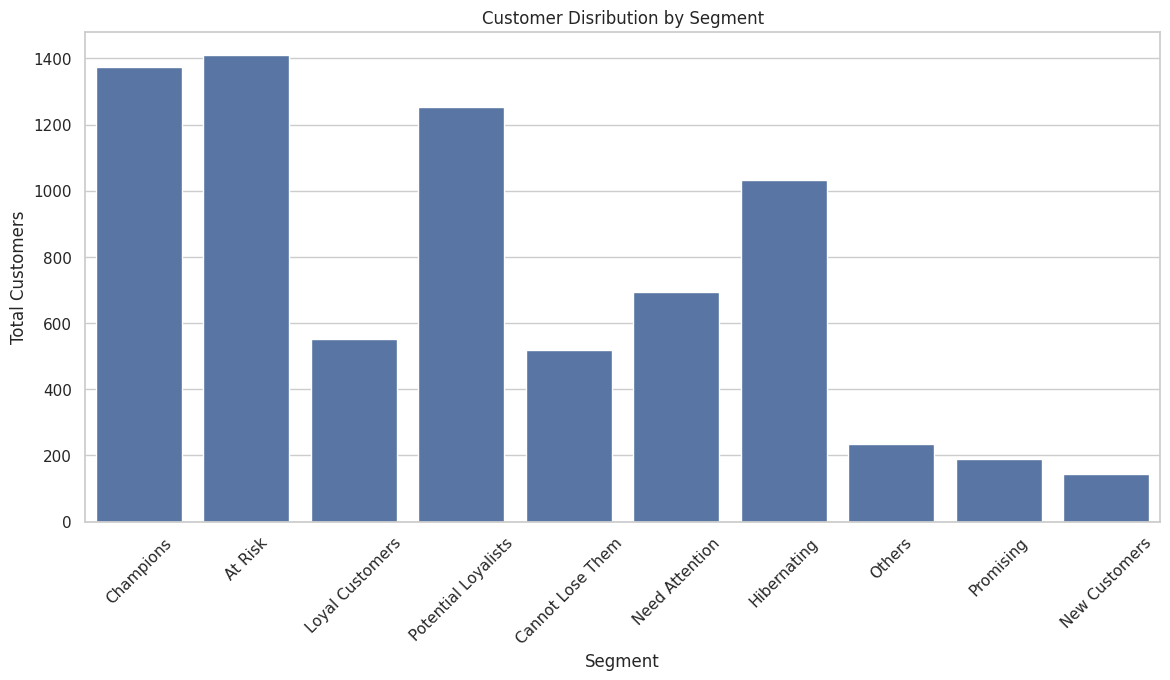

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data = segment_summary,
    x = "segment",
    y = "total_customers"
)

plt.title("Customer Disribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Customers")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

## Revenue Segment

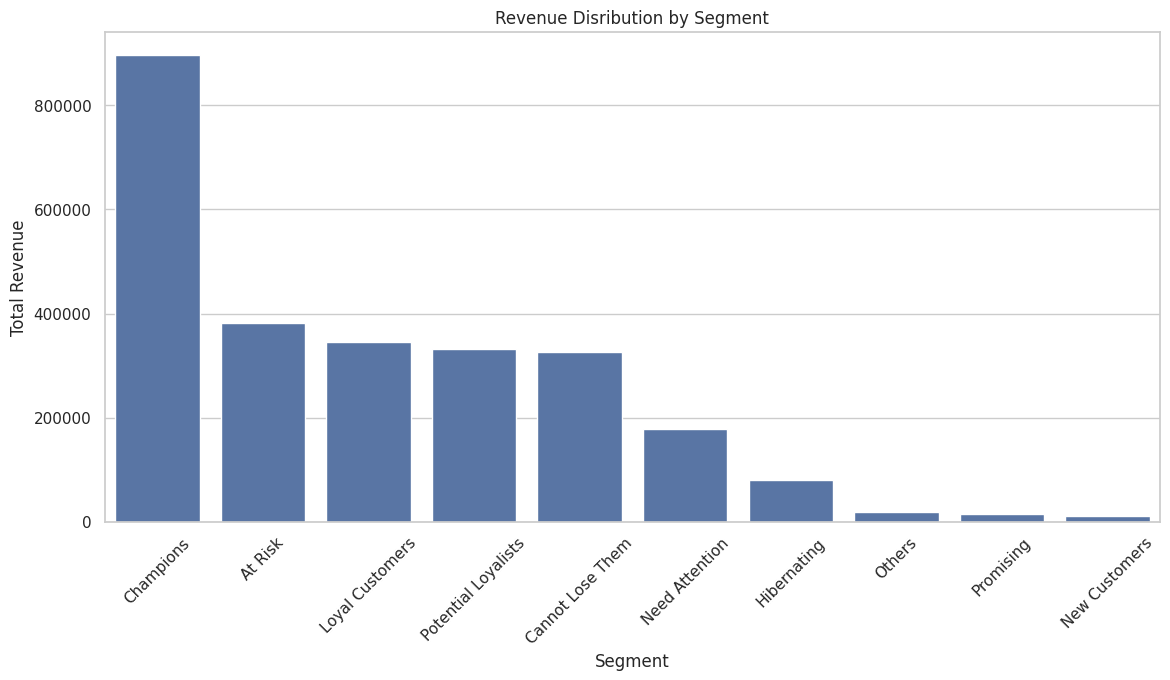

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data = segment_summary,
    x = "segment",
    y = "total_revenue"
)

plt.title("Revenue Disribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

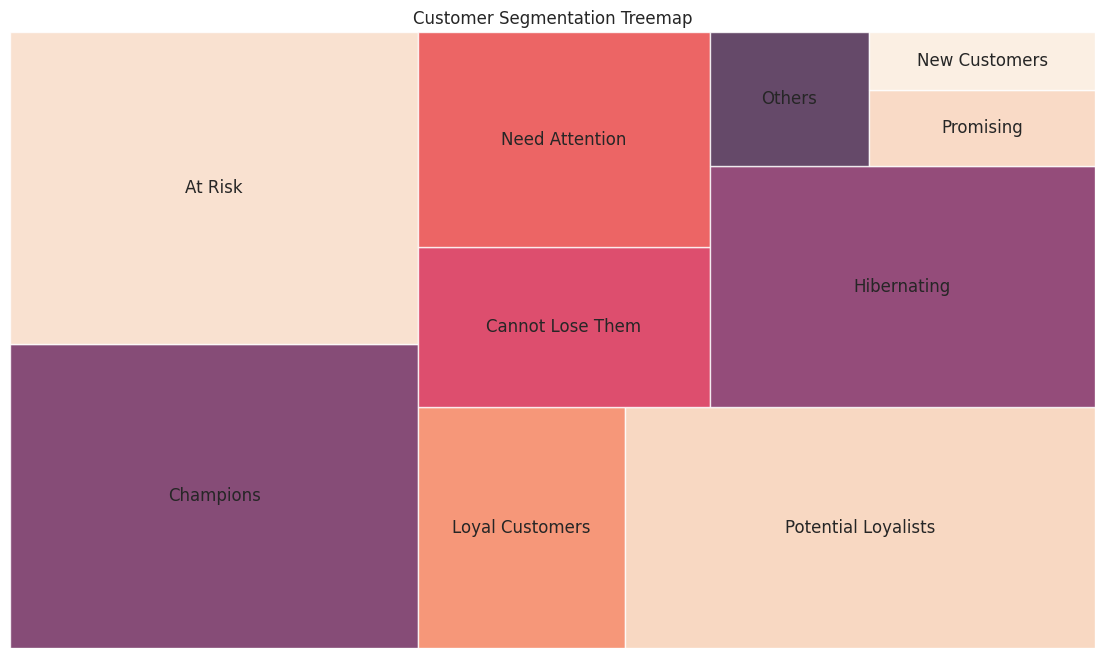

In [ ]:
plt.figure(figsize=(14, 8))

squarify.plot(
    sizes=segment_summary["total_customers"],
    label=segment_summary["segment"],
    alpha=0.8
)

plt.title("Customer Segmentation Treemap")
plt.axis("off")
plt.show()

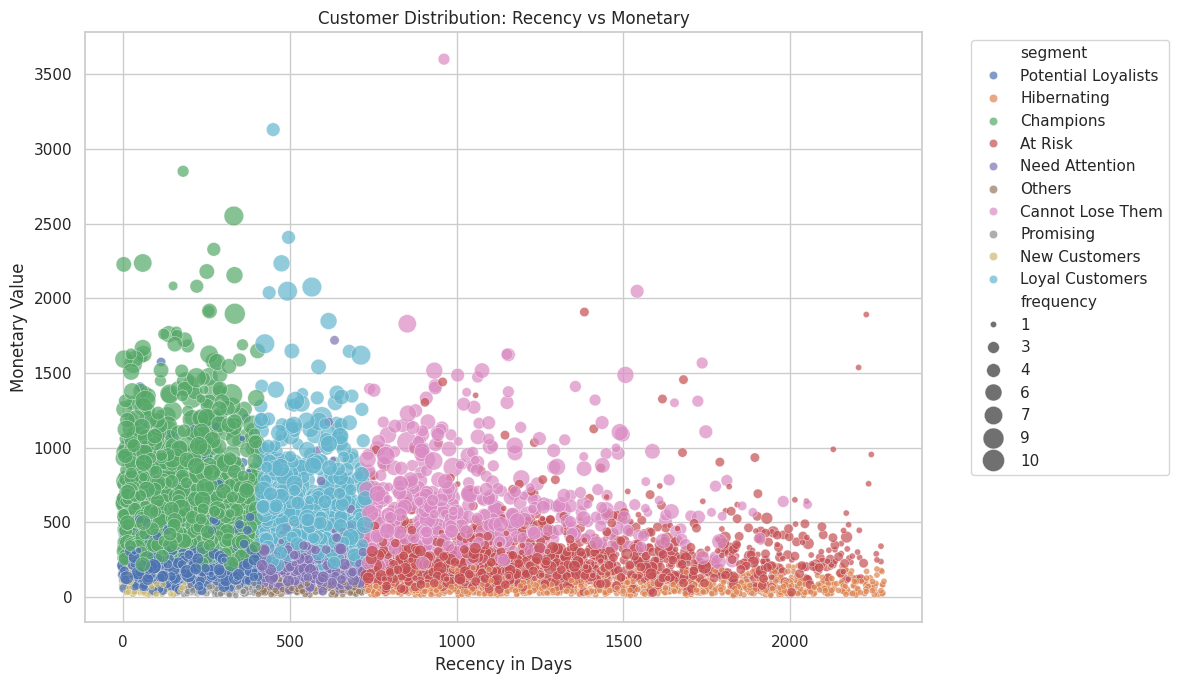

In [ ]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=RFM,
    x="recency",
    y="monetary",
    hue="segment",
    size="frequency",
    sizes=(20, 250),
    alpha=0.7
)

plt.title("Customer Distribution: Recency vs Monetary")
plt.xlabel("Recency in Days")
plt.ylabel("Monetary Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Revenue Contribution Analysis

In [ ]:
# Pareto costumer analysis
pareto = RFM.sort_values(
    "monetary",
    ascending=False
)

In [ ]:
pareto["cummulative_revenue"] = pareto["monetary"].cumsum()
pareto["cummulative_percentage"] = (
    pareto["cummulative_revenue"]
    / pareto["monetary"].sum()
    * 100
)
pareto["custumer_rank_pct"] = (
    np.arange(1, len(pareto) + 1)
    /len(pareto)
)

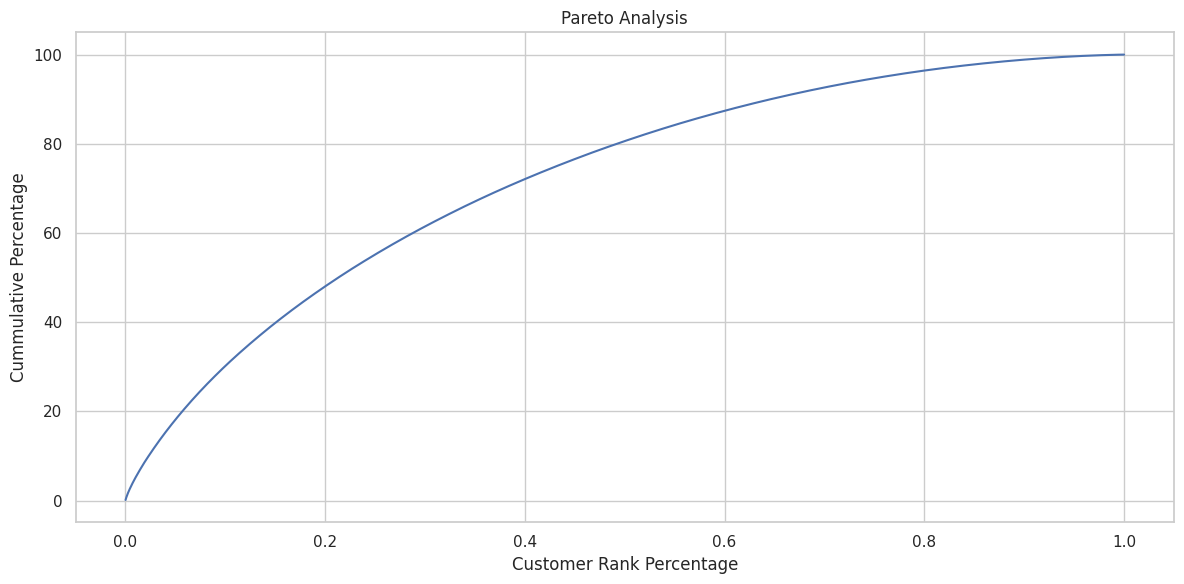

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data = pareto,
    x = "custumer_rank_pct",
    y = "cummulative_percentage"
)

plt.title("Pareto Analysis")
plt.xlabel("Customer Rank Percentage")
plt.ylabel("Cummulative Percentage")
plt.tight_layout()
plt.show()

In [ ]:
top_20_count = int(np.ceil(len(pareto) * 0.20))

top_20_revenue_share = (
    pareto.head(top_20_count)["monetary"].sum()
    / pareto["monetary"].sum()
    * 100
)

print(
    f"Top 20% customers contribute "
    f"{top_20_revenue_share:.2f}% of revenue."
)

Top 20% customers contribute 48.05% of revenue.


# Menggabungkan RFM dengan Customer Profile

In [ ]:
customer_rfm = customers.merge(
    RFM,
    on = "customer_id",
    how = "left"
)

In [ ]:
customer_rfm["segment"] = customer_rfm["segment"].fillna("No Transaction")

In [ ]:
display(customer_rfm.head())

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,...,recency,frequency,monetary,r_score,f_score,m_score,RFM_Score,RFM_Total,fm_avg,segment
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,...,207.0,2.0,511.55,4.0,2.0,4.0,424,10.0,3.0,Potential Loyalists
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,...,987.0,2.0,53.06,2.0,2.0,1.0,221,5.0,1.5,Hibernating
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,...,134.0,3.0,251.44,5.0,3.0,3.0,533,11.0,3.0,Potential Loyalists
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Transaction
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,...,137.0,4.0,342.29,5.0,4.0,4.0,544,13.0,4.0,Champions


# Churn Analysis

In [ ]:
churn_segment = (
    customer_rfm
    .groupby("segment")
    .agg(
        total_customers = ("customer_id", "nunique"),
        total_revenue = ("monetary", "sum"),
        churn_rate = ("churned", "mean")
    )
    .reset_index()
)

In [ ]:
churn_segment["churn_rate"] *=100
churn_segment = churn_segment.sort_values(
    "churn_rate",
    ascending=False
)

display(churn_segment)

,segment,total_customers,total_revenue,churn_rate
0,At Risk,1410,382640.28,11.134752
5,Need Attention,693,177315.34,10.389610
8,Others,236,18207.01,9.745763
4,Loyal Customers,551,345461.04,8.711434
1,Cannot Lose Them,519,326964.78,8.670520
2,Champions,1374,896877.19,8.588064
6,New Customers,145,11348.47,8.275862
9,Potential Loyalists,1253,331775.72,8.060654
3,Hibernating,1031,80778.11,8.050436
7,No Transaction,599,0.00,7.345576


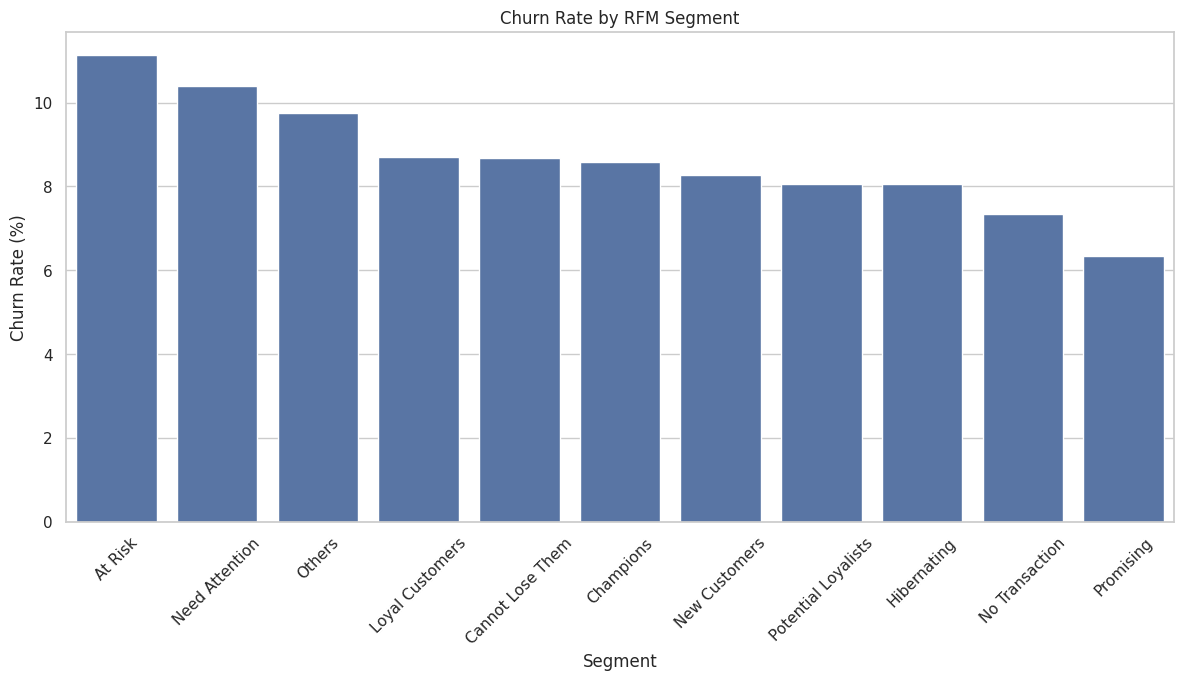

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data = churn_segment,
    x = "segment",
    y = "churn_rate"
)

plt.title("Churn Rate by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [ ]:
customer_rfm.groupby("churned")[
    ["recency", "frequency", "monetary"]
].mean()

,recency,frequency,monetary
churned,,,
0,699.267756,2.775632,349.161743
1,743.171386,2.707899,350.622906


# Membership Analysis

In [ ]:
membership_rfm = (
    customer_rfm
    .groupby("membership_tier")
    .agg(
        total_customers = ("customer_id", "nunique"),
        total_revenue = ("monetary", "sum"),
        avg_recency = ("recency", "mean"),
        avg_frequency = ("frequency", "mean"),
        avg_monetary = ("monetary", "mean"),
        churn_rate = ("churned", "mean")
    )
    .reset_index()
)

In [ ]:
membership_rfm["churn_rate"] *= 100

display(membership_rfm)

,membership_tier,total_customers,total_revenue,avg_recency,avg_frequency,avg_monetary,churn_rate
0,Free,4443,1426761.39,701.431851,2.784319,348.500584,9.520594
1,Gold,1177,381807.22,686.494075,2.762990,348.046691,9.855565
2,Platinum,644,205917.75,714.605657,2.728785,342.625208,8.229814
3,Silver,1736,570640.14,715.050342,2.751398,354.655152,7.085253


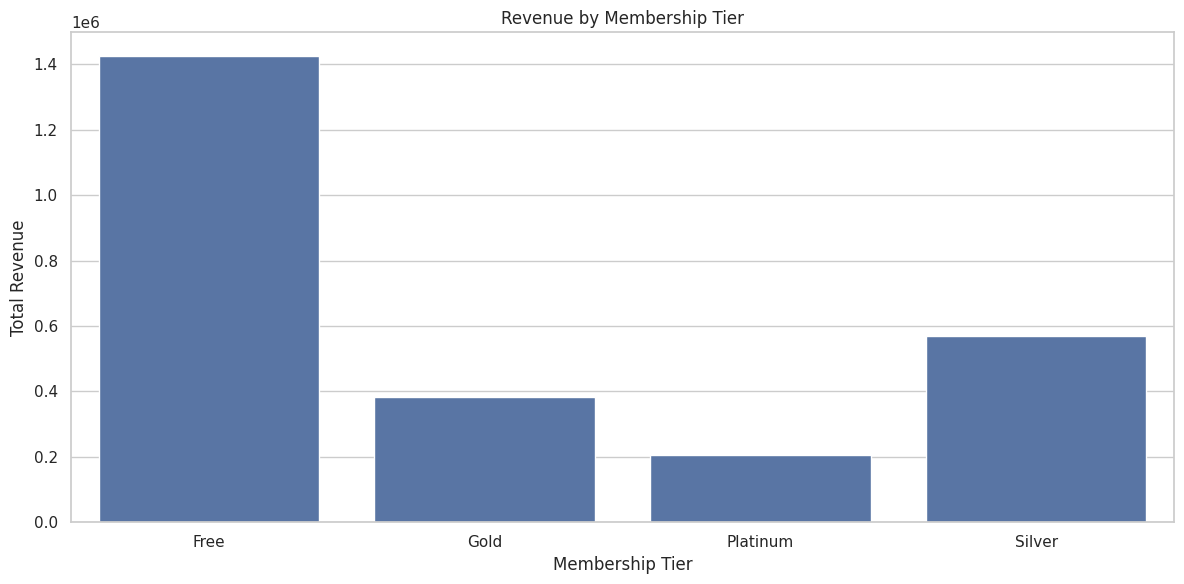

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data = membership_rfm,
    x = "membership_tier",
    y = "total_revenue"
)

plt.title("Revenue by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

In [ ]:
membership_segment = pd.crosstab(
    customer_rfm["membership_tier"],
    customer_rfm["segment"],
    normalize="index"
)*100

display(membership_segment)

segment,At Risk,Cannot Lose Them,Champions,Hibernating,Loyal Customers,Need Attention,New Customers,No Transaction,Others,Potential Loyalists,Promising
membership_tier,,,,,,,,,,,
Free,17.330632,6.819716,17.555706,13.031735,6.887238,8.260185,1.733063,7.855053,3.083502,15.237452,2.205717
Gold,18.266780,4.672897,18.351742,12.319456,6.457094,9.600680,2.124044,6.796941,3.143585,15.717927,2.548853
Platinum,18.788820,5.900621,15.372671,11.490683,7.608696,9.006211,2.018634,6.677019,2.329193,18.322981,2.484472
Silver,17.511521,7.085253,16.071429,13.421659,6.912442,8.928571,1.728111,7.315668,2.707373,15.725806,2.592166


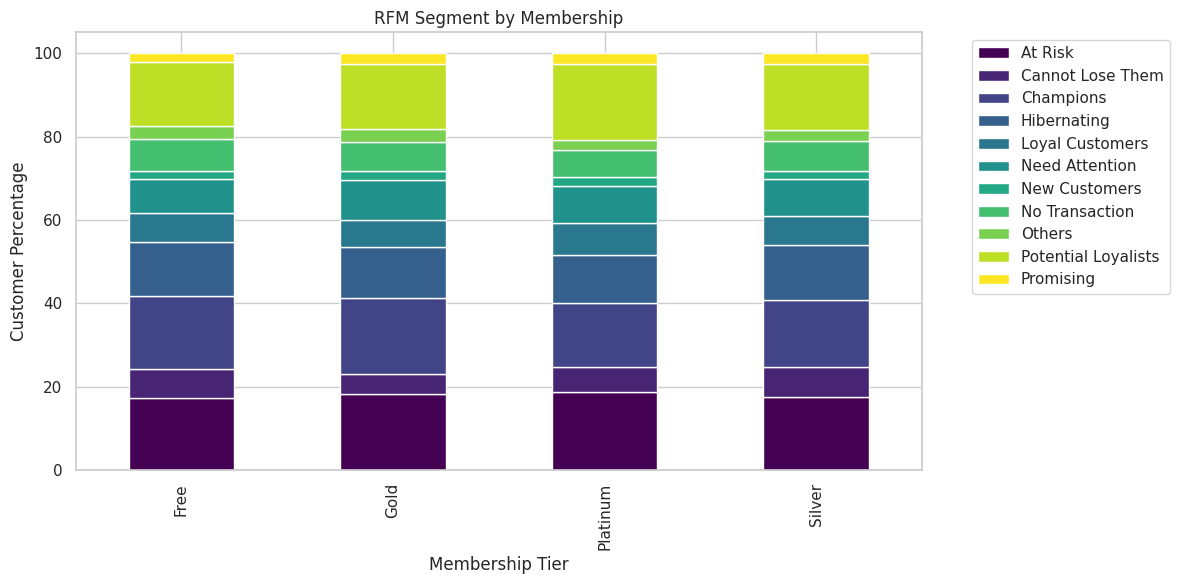

In [ ]:
membership_segment.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    cmap="viridis" # Added colormap for more diverse colors
)

plt.title("RFM Segment by Membership")
plt.xlabel("Membership Tier")
plt.ylabel("Customer Percentage")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Acquisition Channel Analysis

In [ ]:
channel_rfm = (
    customer_rfm
    .dropna(subset=["recency"])
    .groupby("acquisition_channel")
    .agg(
        total_customers=("customer_id", "nunique"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

In [ ]:
channel_rfm["revenue_per_customer"] = (
    channel_rfm["total_revenue"]
    / channel_rfm["total_customers"]
)

channel_rfm["churn_rate"] *= 100

display(
    channel_rfm.sort_values(
        "revenue_per_customer",
        ascending=False
    )
)

,acquisition_channel,total_customers,avg_recency,avg_frequency,avg_monetary,total_revenue,churn_rate,revenue_per_customer
3,Paid Ad,1180,708.721186,2.819492,358.630754,423184.29,9.152542,358.630754
2,Organic Search,2019,673.920258,2.788509,355.028539,716802.62,7.875186,355.028539
0,Direct,763,714.491481,2.769332,351.171756,267944.05,9.960682,351.171756
4,Referral,436,705.694954,2.830275,348.135413,151787.04,10.321101,348.135413
1,Email Campaign,1391,723.020129,2.715313,341.545744,475090.13,9.273904,341.545744
5,Social Media,1612,712.929901,2.739454,341.388567,550318.37,9.553350,341.388567


# Product Preference Analysis

In [ ]:
completed_orders

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,total_amount_usd,payment_method,device_used,delivery_days,delivery_date,order_status,returned,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,74.23,Credit Card,Desktop,3,2020-08-30,Delivered,0,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,24.27,Credit Card,Mobile,2,2024-04-13,Delivered,0,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,94.86,PayPal,Desktop,3,2023-06-28,Delivered,0,3.2,17,0
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,208.02,Debit Card,Mobile,5,2020-04-29,Delivered,0,54.7,2,1
6,O000007,C02205,2023-12-14,2023,12,Q4,Thursday,Pull-up Bar,Sports & Outdoors,62.33,...,139.62,Credit Card,Desktop,4,2023-12-18,Delivered,0,10.9,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,O024996,C07416,2023-03-15,2023,3,Q1,Wednesday,Sports Socks 6-Pack,Clothing & Apparel,59.18,...,50.30,Credit Card,Mobile,4,2023-03-19,Delivered,0,7.9,7,1
24996,O024997,C04387,2024-04-22,2024,4,Q2,Monday,Shower Curtain,Home & Kitchen,81.17,...,448.31,Cryptocurrency,Desktop,4,2024-04-26,Delivered,0,134.7,16,1
24997,O024998,C07566,2023-06-07,2023,6,Q2,Wednesday,Collagen Peptides,Health & Wellness,28.92,...,177.62,Credit Card,Desktop,5,2023-06-12,Delivered,0,4.2,16,1
24998,O024999,C04986,2024-05-06,2024,5,Q2,Monday,Energy Bars 12-Pack,Food & Grocery,19.43,...,41.97,Credit Card,Mobile,4,2024-05-10,Delivered,0,13.5,9,1


In [ ]:
order_segments = completed_orders.merge(
    RFM.reset_index()[["customer_id", "segment"]],
    on="customer_id",
    how="left"
)

In [ ]:
category_segment = (
    order_segments
    .groupby(["segment", "category"])
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_amount_usd", "sum")
    )
    .reset_index()
)

In [ ]:
top_category_segment = (
    category_segment
    .sort_values(
        ["segment", "total_revenue"],
        ascending=[True, False]
    )
    .groupby("segment")
    .head(3)
)

display(top_category_segment)

,segment,category,total_orders,total_revenue
4,At Risk,Electronics,607,143147.07
3,At Risk,Clothing & Apparel,502,56786.32
7,At Risk,Home & Kitchen,367,49205.32
18,Cannot Lose Them,Electronics,438,145466.61
17,Cannot Lose Them,Clothing & Apparel,339,43062.38
21,Cannot Lose Them,Home & Kitchen,242,42658.54
32,Champions,Electronics,1265,352531.05
35,Champions,Home & Kitchen,802,127277.30
31,Champions,Clothing & Apparel,959,124513.55
45,Hibernating,Clothing & Apparel,180,14011.16


In [ ]:
preferred_category_summary = (
    customer_rfm
    .groupby(["segment", "preferred_category"])
    .size()
    .reset_index(name="total_customers")
)

In [ ]:
top_preferred_category = (
    preferred_category_summary
    .sort_values(
        ["segment", "total_customers"],
        ascending=[True, False]
    )
    .groupby("segment")
    .head(3)
)

display(top_preferred_category)

,segment,preferred_category,total_customers
4,At Risk,Electronics,254
3,At Risk,Clothing & Apparel,234
7,At Risk,Home & Kitchen,156
18,Cannot Lose Them,Electronics,93
17,Cannot Lose Them,Clothing & Apparel,83
21,Cannot Lose Them,Home & Kitchen,52
32,Champions,Electronics,278
31,Champions,Clothing & Apparel,218
35,Champions,Home & Kitchen,170
46,Hibernating,Electronics,192


# Discount & Return Analysis

In [ ]:
discount_segment = (
    order_segments
    .groupby("segment")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_amount_usd", "sum"),
        avg_order_value=("total_amount_usd", "mean"),
        avg_discount=("discount_amount_usd", "mean")
    )
    .reset_index()
)

display(discount_segment)

,segment,total_orders,total_revenue,avg_order_value,avg_discount
0,At Risk,3077,382640.28,124.354982,6.694079
1,Cannot Lose Them,2014,326964.78,162.345968,7.780437
2,Champions,6205,896877.19,144.541046,6.804533
3,Hibernating,1169,80778.11,69.100180,3.833593
4,Loyal Customers,2398,345461.04,144.062152,6.356218
5,Need Attention,1720,177315.34,103.090314,5.819512
6,New Customers,180,11348.47,63.047056,2.315889
7,Others,299,18207.01,60.893010,3.472174
8,Potential Loyalists,3198,331775.72,103.744753,5.901560
9,Promising,237,13758.56,58.052996,3.911814


In [ ]:
orders_with_segment = orders.merge(
    RFM.reset_index()[["customer_id", "segment"]],
    on="customer_id",
    how="left"
)

orders_with_segment["is_returned"] = (
    orders_with_segment["order_status"]
    .str.lower()
    .eq("returned")
)

In [ ]:
return_segment = (
    orders_with_segment
    .groupby("segment")
    .agg(
        total_orders=("order_id", "nunique"),
        returned_orders=("is_returned", "sum"),
        return_rate=("is_returned", "mean")
    )
    .reset_index()
)

return_segment["return_rate"] *= 100

display(return_segment)

,segment,total_orders,returned_orders,return_rate
0,At Risk,3859,356,9.225188
1,Cannot Lose Them,2338,149,6.372968
2,Champions,6946,327,4.707745
3,Hibernating,1767,274,15.506508
4,Loyal Customers,2700,128,4.740741
5,Need Attention,2107,177,8.400570
6,New Customers,259,30,11.583012
7,Others,439,69,15.717540
8,Potential Loyalists,3897,318,8.160123
9,Promising,349,49,14.040115


# Customers Prioritization

## Retention Priority

In [ ]:
retention_segments = [
    "At Risk",
    "Cannot Lose Them",
    "Need Attention"
]

retention_priority = (
    customer_rfm[
        customer_rfm["segment"].isin(retention_segments)
    ]
    .sort_values(
        ["monetary", "frequency"],
        ascending=False
    )
)

In [ ]:
display(
    retention_priority[
        [
            "customer_id",
            "segment",
            "recency",
            "frequency",
            "monetary",
            "membership_tier",
            "acquisition_channel",
            "preferred_category",
            "churned"
        ]
    ].head(20)
)

,customer_id,segment,recency,frequency,monetary,membership_tier,acquisition_channel,preferred_category,churned
5297,C05298,Cannot Lose Them,962.0,3.0,3602.81,Platinum,Social Media,Food & Grocery,0
2848,C02849,Cannot Lose Them,1541.0,4.0,2047.18,Free,Direct,Health & Wellness,0
1744,C01745,At Risk,1383.0,2.0,1907.93,Free,Organic Search,Sports & Outdoors,0
2494,C02495,At Risk,2228.0,1.0,1890.97,Gold,Social Media,Clothing & Apparel,0
2362,C02363,Cannot Lose Them,852.0,7.0,1829.52,Silver,Paid Ad,Books,0
1915,C01916,Need Attention,634.0,2.0,1718.74,Free,Organic Search,Electronics,1
6354,C06355,Cannot Lose Them,1151.0,3.0,1624.68,Gold,Organic Search,Clothing & Apparel,0
5194,C05195,Cannot Lose Them,1155.0,4.0,1621.86,Silver,Organic Search,Toys & Games,0
6062,C06063,Cannot Lose Them,1736.0,3.0,1566.39,Gold,Organic Search,Pet Supplies,0
2184,C02185,At Risk,2205.0,1.0,1536.25,Platinum,Paid Ad,Home & Kitchen,0


## VIP

In [ ]:
vip_customers = (
    customer_rfm[
        customer_rfm["segment"].isin(
            ["Champions", "Loyal Customers"]
        )
    ]
    .sort_values(
        "monetary",
        ascending=False
    )
)

## Win-Back Customers

In [ ]:
winback_customers = (
    customer_rfm[
        customer_rfm["segment"].isin(
            ["At Risk", "Cannot Lose Them", "Hibernating"]
        )
    ]
    .sort_values(
        ["monetary", "frequency"],
        ascending=False
    )
)

In [ ]:
print(f"Total kandidat retention priority : {len(retention_priority):,} customers")
print(f"Total kandidat VIP                 : {len(vip_customers):,} customers")
print(f"Total kandidat win-back             : {len(winback_customers):,} customers")
print()

# Top 10 win-back berdasarkan monetary tertinggi -- prioritas budget terbatas
display(
    winback_customers[[
        "customer_id", "segment", "recency", "frequency", "monetary",
        "membership_tier", "acquisition_channel", "preferred_category", "churned"
    ]].head(10)
)

# Problem Answer
1. Bagaimana segmentasi pelanggan berdasarkan perilaku transaksi dapat
digunakan untuk meningkatkan retensi pelanggan dan kontribusi pendapatan perusahaan? </br>
Hasil proses analisis menunjukkan bahwa strategi retensi dan kontribusi pendapataan perusahaan tidak bisa disamaratakan. Dengan kata lain RFM mengubah pelanggan yang homogen menjadi kelas kelas dengan kebutuhan strategi yang berbeda beda. Hal ini membantu dalam mengalokasikan budget dan effort lebih efisien
</br>

2. Bagaimana distribusi pelanggan berdasarkan nilai Recency, Frequency, dan Monetary?</br>
    - **Recency**: Median 557 dengan jangkauan 2280. Hal ini menunjukkan artinya ada separuh pelanggan yang tidak melakukan transaksi lebih dari 1.5 tahun lamanya.
    - **Frequency**: Rata rata pelanggan melakuakn transaksi sebanyak 2-3 kali dan sangat sedikit yang sampai 8-10 kali transaksi.
    - **Monetary**: Nilai median 266, tapi rata rata 349 dan nilai maksimum mencapai 3,603. Hal ini menunjukkan hanya segelitir orang yang mengangkat nilai rata rata.
</br>
</br>

3. Segmen pelanggan mana yang memberikan kontribusi pendapatan terbesar?</br>
**Champions** memberikan kontribusi revenue terbesar dengan total 34.7% dari keseluruhan, walaupun jumlah pelanggannya hanya 18,6% dari keseluruhan. Hasil Pareto menunjukkan 20% pelanggan tertinggi menyumbang revenue sebanyak 48.05%. Selain itu, **Loyal Customers** menyumbang 13.4% dan **Cannot Lost Them** menyumbang 10.2%
</br>

4. Segmen pelanggan mana yang memiliki risiko churn tertinggi?</br>
3 segmen yang paling mengkhawatirkan ada pada **At Risk**(11,1%), **Need Attention**(10.4%), dan **Others**(9.7%).
</br>

5. Membership tier dan acquisition channel mana yang menghasilkan pelanggan paling bernilai?</br>
Membership tier menunjukkan nilai rata rata monetery yang hampir sama, ada pada angka 342-355. Ini merupakan tanda program membership belum mampu mendorong tier tinggi untuk melakukan spending.
</br>

6. Produk dan kategori apa yang paling banyak diminati oleh pelanggan bernilai tinggi?</br>
Katerogry **Electronic** adalah ketegori yang paling diminati, disusul kategori **Clothing & Apparel** dan **Home & Kitchen**. Ketiga kategori ini diminati oleh segmen bernilai tinggi.
</br>

7. Pelanggan mana yang harus diprioritaskan untuk program retensi dan win-back campaign?</br>
    -  Retention priority untuk mencegah churn diberlakukan pada segmen **At Risk**, **Cannot Lost Them**, dan **Need Attention**. Total ada 2,720 pelanggan. Prioritas tertinggi diberlakukan kepeda pelanggan dengan tingkat monetery besar, namun recency rendah
    - VIP diberlakukan untuk menjaga loyalitas diberlakukan pada segmen **Champions** dan **Loyal Customers**. Total ada 1,925 pelanggan.
    - Win-Back dilakukan untuk merecall pelanggan yang sudah lama tidak aktif yang ada pada segmen **At Risk**, **Cannot Lost Them**, dan **Hibernating**. Program difokuskan ke monetary tertinggi.


# Business Insights

1. Revenue Concentration</br>
Segmen Champions hanya mencakup 18.6% pelanggan, tetapi memberikan kontribusi sebesar 34.7% terhadap total revenue. Secara keseluruhan, top 20% pelanggan paling tinggi berkontribusi 48.05% dari total revenue. Hal ini menunjukkan bahwa revenue perusahaan sangat bergantung pada sebagian kecil pelanggan bernilai tinggi.
</br>

2. Customer Retention</br>
Segmen **At Risk** memiliki rata-rata Recency sebesar 1,251 hari dan churn rate sebesar 11.1%, disusul **Need Attention** sebesar 10.4%.Pelanggan dalam segmen tersebut perlu menjadi prioritas retention campaign, terutama karena mereka historis pernah aktif
</br>

3. Membership Performance</br>
Keempat membership tier ternyata memiliki rata-rata Frequency dan Monetary yang hampir seragam tanpa perbedaan besar antar tier. Membership Gold memiliki churn rate tertinggi (9.86%), sementara
Silver memiliki churn rate terendah (7.09%). Karena tier Platinum tidak menunjukkan value yang jauh lebih tinggi dari tier Free, manfaat
program membership perlu dievaluasi.
</br>

4. Acquisition Channel</br>
Channel Organic Search menghasilkan pelanggan dengan revenue per customer tinggi (355) dan churn rate terendah (7.9%) di antara semua channel, dengan volume customer terbesar kedua (2,019 orang) hal  inin menjadikannya channel paling bernilai secara keseluruhan. Sementara itu, channel Referral menghasilkan sedikit pelanggan (436 orang) dengan churn rate tertinggi (10.3%), dan Paid Ad punya revenue per customer tertinggi (359) namun churn rate cukup tinggi (9.2%). Menunjukkan kualitas akuisisinya kurang stabil dibanding Organic Search.
</br>

5. Product Preferences</br>
Pelanggan **Champions** dan **Loyal Customers** paling banyak membeli kategori Electronics, diikuti Clothing & Apparel dan Home & Kitchen. Ketiga kategori ini dapat digunakan untuk personalized recommendation, cross-selling, dan loyalty reward.


# Business Recommendations

1. Champions

- Berikan program VIP dan loyalty rewards.
- Tawarkan early access terhadap produk baru.
- Gunakan referral program untuk memperoleh pelanggan berkualitas tinggi.</br>
</br>

2. Loyal Customers

- Terapkan strategi cross-selling dan upselling.
- Berikan rekomendasi berdasarkan kategori favorit.
- Dorong pelanggan naik ke membership tier yang lebih tinggi.</br>
</br>

3. Potential Loyalists

- Berikan insentif untuk pembelian kedua atau ketiga.
- Gunakan personalized product recommendation.
- Promosikan program membership.</br>
</br>

4. At Risk

- Jalankan reactivation campaign berdasarkan produk yang pernah dibeli.
- Berikan voucher dengan periode terbatas.
- Prioritaskan pelanggan dengan nilai Monetary tinggi.</br>
</br>

5. Cannot Lose Them

- Hubungi pelanggan menggunakan campaign yang lebih personal.
- Tawarkan benefit eksklusif atau customer support khusus.
- Evaluasi pengalaman pembelian terakhir mereka.</br>
</br>

6. Hibernating

- Gunakan win-back campaign dengan biaya terkendali.
- Hindari memberikan diskon besar kepada pelanggan dengan nilai historis rendah.